# <h1 style="text-align: center;">Question 1: How severe is heart failure at admission by sex? (NYHA class and Killip grade)</h1>

This notebook answers Question 1 using two tables produced by our cleaning notebook
**`Team05_PyCraft_1_Cleaning.ipynb`**: `cleaned/demography_cleaned.csv` (for `gender`) and
`cleaned/cardiac_cleaned.csv` (for the two standard clinical severity scales recorded at admission).

Team05 renamed the cardiac columns, so this notebook uses the Team05 names:

| Original column | Team05 cleaned column | Used here as |
|---|---|---|
| `inpatient_number` | `patient_id` | merge key |
| `nyha_cardiac_function_classification` | `heart_failure_severity` | `nyha_class` |
| `killip_grade` | `heart_damage_level` | `killip_grade` |
| (new in Team05) | `severe_hf` = NYHA ≥ 3 and Killip ≥ 3 | `severe_hf` |

- **NYHA class** (New York Heart Association) grades how much heart
  failure limits physical activity: class 2 = mild, class 3 = moderate,
  class 4 = severe (symptoms even at rest).
- **Killip grade** grades the severity of acute heart failure on
  admission: grade 1 = no signs of failure, grade 2 = mild (rales/S3),
  grade 3 = pulmonary edema, grade 4 = cardiogenic shock (most severe).

**Run order:** run `Team05_PyCraft_1_Cleaning.ipynb` first, then this notebook.

## Step 1 — Load the two tables cleaned by Team05

We read the cleaned files written by the final cell of the Team05 notebook, instead of the raw CSVs,
so this analysis uses exactly the same cleaned data as the rest of the project (renamed columns,
patient 5 removed, text standardised). We then confirm those cleaning steps are present.

In [1]:
from pathlib import Path
import pandas as pd

# Team05_PyCraft_1_Cleaning.ipynb is run from inside the project folder, and its final cell
# saves every cleaned table to <project>/cleaned/<table>_cleaned.csv.
# We look for that folder whether this notebook is opened inside the project folder or one level
# above it. (This replaces os.chdir(...), which fails when the cell is run a second time.)
CANDIDATES = [Path("."), Path("Python_Hackathon_SEP_2026")]
PROJECT = next((p for p in CANDIDATES if (p / "cleaned" / "demography_cleaned.csv").exists()), None)
if PROJECT is None:
    raise FileNotFoundError(
        "Team05 cleaned files not found. Run Team05_PyCraft_1_Cleaning.ipynb first: "
        "its last cell writes the cleaned tables to the 'cleaned' folder.")
CLEANED = PROJECT / "cleaned"
print("Using Team05 cleaned files from:", CLEANED.as_posix())

def load_cleaned(file_name):
    """Read one Team05 output file and give patient_id the same string format Team05 applies
    to demography (so every table merges on identical keys)."""
    d = pd.read_csv(CLEANED / file_name)
    d["patient_id"] = d["patient_id"].astype(str).str.replace(r"\.0$", "", regex=True)
    return d

demo = load_cleaned("demography_cleaned.csv")
cc = load_cleaned("cardiac_cleaned.csv")

# Confirm the Team05 cleaning steps this analysis relies on are present in the files
assert "5" not in set(demo["patient_id"]), "Patient 5 should have been removed by the Team05 notebook"
assert set(demo["gender"].dropna().unique()) <= {"Female", "Male"}, "gender should be standardised to Female/Male"
assert {"heart_failure_severity", "heart_damage_level", "severe_hf"} <= set(cc.columns), "expected Team05 cardiac column names"
assert demo["patient_id"].is_unique and cc["patient_id"].is_unique

print("demography_cleaned:", demo.shape)
print("cardiac_cleaned:", cc.shape)

Using Team05 cleaned files from: Python_Hackathon_SEP_2026/cleaned
demography_cleaned: (2008, 7)
cardiac_cleaned: (2008, 15)


## Step 2 — Merge on `patient_id`

We only need `gender` from demography and the two severity scores (plus Team05's `severe_hf` flag)
from the cardiac table. We confirm first that neither severity column has missing values, so an
inner join won't quietly drop any patients.

In [2]:
print("Missing NYHA class (heart_failure_severity):", cc["heart_failure_severity"].isna().sum())
print("Missing Killip grade (heart_damage_level):", cc["heart_damage_level"].isna().sum())

severity = demo[["patient_id", "gender"]].merge(
    cc[["patient_id", "heart_failure_severity", "heart_damage_level", "severe_hf"]],
    on="patient_id", how="inner", validate="one_to_one"
)

# Readable analysis names for the two scales (the Team05 columns are kept alongside them),
# treated as categories for the tables below
severity["nyha_class"] = severity["heart_failure_severity"].astype("category")
severity["killip_grade"] = severity["heart_damage_level"].astype("category")
severity["gender"] = severity["gender"].astype("category")

print("Merged table:", severity.shape)
severity.head()

Missing NYHA class (heart_failure_severity): 0
Missing Killip grade (heart_damage_level): 0
Merged table: (2008, 7)


,patient_id,gender,heart_failure_severity,heart_damage_level,severe_hf,nyha_class,killip_grade
0,827040,Female,3,2,0,3,2
1,857781,Male,3,3,1,3,3
2,743087,Female,3,1,0,3,1
3,866418,Male,2,2,0,2,2
4,775928,Male,3,2,0,3,2


## Step 3 — Overall severity distribution (before splitting by sex)

A quick baseline: how severe is heart failure across the whole admitted
population, regardless of sex?

In [3]:
print("=== NYHA class distribution (all patients) ===")
print(severity["nyha_class"].value_counts().sort_index())
print((severity["nyha_class"].value_counts(normalize=True).sort_index() * 100).round(1).astype(str) + "%")

print("\n=== Killip grade distribution (all patients) ===")
print(severity["killip_grade"].value_counts().sort_index())
print((severity["killip_grade"].value_counts(normalize=True).sort_index() * 100).round(1).astype(str) + "%")

=== NYHA class distribution (all patients) ===
nyha_class
2     353
3    1039
4     616
Name: count, dtype: int64
nyha_class
2    17.6%
3    51.7%
4    30.7%
Name: proportion, dtype: str

=== Killip grade distribution (all patients) ===
killip_grade
1     527
2    1029
3     392
4      60
Name: count, dtype: int64
killip_grade
1    26.2%
2    51.2%
3    19.5%
4     3.0%
Name: proportion, dtype: str


## Step 4 — NYHA class by sex

We cross-tabulate sex against NYHA class two ways: raw counts (how many
patients), and row percentages (what share of each sex falls in each
class) — the percentages are what actually let us compare severity
*between* sexes fairly, since there are more women than men in this
dataset.

In [4]:
nyha_counts = pd.crosstab(severity["gender"], severity["nyha_class"])
nyha_pct = pd.crosstab(severity["gender"], severity["nyha_class"], normalize="index") * 100

print("=== NYHA class by sex: counts ===")
print(nyha_counts)
print("\n=== NYHA class by sex: row % (share of each sex) ===")
print(nyha_pct.round(1))

=== NYHA class by sex: counts ===
nyha_class    2    3    4
gender                   
Female      226  608  329
Male        127  431  287

=== NYHA class by sex: row % (share of each sex) ===
nyha_class     2     3     4
gender                      
Female      19.4  52.3  28.3
Male        15.0  51.0  34.0


## Step 5 — Killip grade by sex

Same two views for Killip grade.

In [5]:
killip_counts = pd.crosstab(severity["gender"], severity["killip_grade"])
killip_pct = pd.crosstab(severity["gender"], severity["killip_grade"], normalize="index") * 100

print("=== Killip grade by sex: counts ===")
print(killip_counts)
print("\n=== Killip grade by sex: row % (share of each sex) ===")
print(killip_pct.round(1))

=== Killip grade by sex: counts ===
killip_grade    1    2    3   4
gender                         
Female        326  587  224  26
Male          201  442  168  34

=== Killip grade by sex: row % (share of each sex) ===
killip_grade     1     2     3    4
gender                             
Female        28.0  50.5  19.3  2.2
Male          23.8  52.3  19.9  4.0


## Step 6 — Focus on the most severe category of each scale

NYHA class 4 (symptoms at rest) and Killip grade 4 (cardiogenic shock) are
the most clinically severe levels of each scale. Comparing the share of
each sex that falls into these top-severity groups is often the most
direct way to answer how severe heart failure is, by sex.

In [6]:
most_severe_nyha = nyha_pct[4] if 4 in nyha_pct.columns else nyha_pct.iloc[:, -1]
most_severe_killip = killip_pct[4] if 4 in killip_pct.columns else killip_pct.iloc[:, -1]

print("Share of each sex in NYHA class 4 (most severe):")
print(most_severe_nyha.round(1).astype(str) + "%")

print("\nShare of each sex in Killip grade 4 / cardiogenic shock (most severe):")
print(most_severe_killip.round(1).astype(str) + "%")

Share of each sex in NYHA class 4 (most severe):
gender
Female    28.3%
Male      34.0%
Name: 4, dtype: str

Share of each sex in Killip grade 4 / cardiogenic shock (most severe):
gender
Female    2.2%
Male      4.0%
Name: 4, dtype: str


## Step 7 — Team05's combined severity flag (`severe_hf`) by sex

The Team05 cleaning notebook created `severe_hf` = 1 when a patient is **both** NYHA class ≥ 3
and Killip grade ≥ 3 (very symptomatic *and* showing pulmonary oedema or shock). We first confirm
the saved flag matches that rule, then compare its rate between the sexes.

In [7]:
from scipy.stats import chi2_contingency

recomputed = ((severity["heart_failure_severity"] >= 3) & (severity["heart_damage_level"] >= 3)).astype(int)
print("severe_hf matches NYHA>=3 & Killip>=3 for every patient:", bool((recomputed == severity["severe_hf"]).all()))

severe_counts = pd.crosstab(severity["gender"], severity["severe_hf"])
severe_pct = severity.groupby("gender", observed=True)["severe_hf"].mean() * 100

print("\n=== severe_hf by sex: counts ===")
print(severe_counts)
print("\n=== Share of each sex flagged severe_hf ===")
print(severe_pct.round(1).astype(str) + "%")

chi2_sev, p_sev, dof_sev, _ = chi2_contingency(severe_counts)
print(f"\nchi2 = {chi2_sev:.3f}, degrees of freedom = {dof_sev}, p-value = {p_sev:.4f}")
print("Significant association (p<0.05)?", p_sev < 0.05)

severe_hf matches NYHA>=3 & Killip>=3 for every patient: True

=== severe_hf by sex: counts ===
severe_hf    0    1
gender             
Female     956  207
Male       666  179

=== Share of each sex flagged severe_hf ===
gender
Female    17.8%
Male      21.2%
Name: severe_hf, dtype: str

chi2 = 3.396, degrees of freedom = 1, p-value = 0.0654
Significant association (p<0.05)? False


## Step 8 — Visualize both scales side-by-side by sex

Grouped bar charts make the severity comparison across sexes easy to read
at a glance.

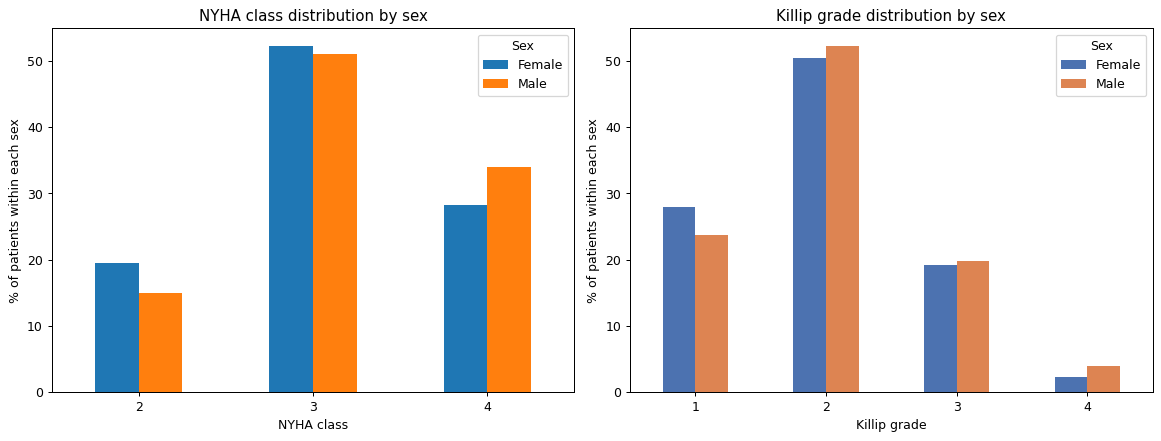

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

nyha_pct.T.plot(kind="bar", ax=axes[0])
axes[0].set_title("NYHA class distribution by sex")
axes[0].set_xlabel("NYHA class")
axes[0].set_ylabel("% of patients within each sex")
axes[0].legend(title="Sex")
axes[0].tick_params(axis="x", rotation=0)

killip_pct.T.plot(kind="bar", ax=axes[1], color=["#4C72B0", "#DD8452"])
axes[1].set_title("Killip grade distribution by sex")
axes[1].set_xlabel("Killip grade")
axes[1].set_ylabel("% of patients within each sex")
axes[1].legend(title="Sex")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

## Step 9 — Is the difference between sexes statistically significant?

A chi-square test of independence tells us whether the severity
distribution (NYHA class, Killip grade) is meaningfully associated with
sex, or whether the differences we see could plausibly be due to chance.
A small p-value (conventionally < 0.05) indicates a statistically
significant association.

In [9]:
from scipy.stats import chi2_contingency

chi2_nyha, p_nyha, dof_nyha, _ = chi2_contingency(nyha_counts)
chi2_killip, p_killip, dof_killip, _ = chi2_contingency(killip_counts)

print("=== Chi-square test: sex vs NYHA class ===")
print(f"chi2 = {chi2_nyha:.3f}, degrees of freedom = {dof_nyha}, p-value = {p_nyha:.4f}")
print("Significant association (p<0.05)?", p_nyha < 0.05)

print("\n=== Chi-square test: sex vs Killip grade ===")
print(f"chi2 = {chi2_killip:.3f}, degrees of freedom = {dof_killip}, p-value = {p_killip:.4f}")
print("Significant association (p<0.05)?", p_killip < 0.05)

=== Chi-square test: sex vs NYHA class ===
chi2 = 10.689, degrees of freedom = 2, p-value = 0.0048
Significant association (p<0.05)? True

=== Chi-square test: sex vs Killip grade ===
chi2 = 9.014, degrees of freedom = 3, p-value = 0.0291
Significant association (p<0.05)? True


## Step 10 — Save the summary tables

We save the counts and percentage tables so they can be dropped straight
into a report or slide deck without re-running the notebook.

In [10]:
output_folder = CLEANED   # the same 'cleaned' folder the Team05 notebook writes to

nyha_counts.to_csv(output_folder / "q1_nyha_by_sex_counts.csv")
nyha_pct.round(2).to_csv(output_folder / "q1_nyha_by_sex_percent.csv")
killip_counts.to_csv(output_folder / "q1_killip_by_sex_counts.csv")
killip_pct.round(2).to_csv(output_folder / "q1_killip_by_sex_percent.csv")
severe_counts.to_csv(output_folder / "q1_severe_hf_by_sex_counts.csv")
severe_pct.round(2).to_csv(output_folder / "q1_severe_hf_by_sex_percent.csv")

print("Saved summary tables to:", output_folder.as_posix())

Saved summary tables to: Python_Hackathon_SEP_2026/cleaned


## Summary

- **Data source:** all results use the tables cleaned by `Team05_PyCraft_1_Cleaning.ipynb`
  (`demography_cleaned.csv`, `cardiac_cleaned.csv`), so they match the rest of the project.
- **NYHA class** (`heart_failure_severity`): report the row-% table above for the exact split;
  compare the "class 4" column between Male and Female to see which sex
  has a higher share of the most severe symptom level.
- **Killip grade** (`heart_damage_level`): same approach — compare the "grade 4" (cardiogenic
  shock) column between sexes.
- **Team05 `severe_hf` flag** (NYHA ≥ 3 and Killip ≥ 3): Step 7 shows whether the combined
  high-severity group differs by sex.
- The chi-square tests tell you whether any sex difference you observe is
  statistically significant or could be due to chance, given this sample
  size.